# 🏨 Agentic Hotel Assistant — Notebook 2: LangGraph Agent
## Agent Workflow + Memory + Conversational Interface

This notebook builds the complete agent:
1. Load all tools from Notebook 1
2. Build the **LangGraph** ReAct agent (nodes + edges)
3. Add **Memory** (conversation history)
4. Interactive chat loop

### Architecture Overview
```
User Input
    │
    ▼
┌─────────────────────────────────────────┐
│           LangGraph Agent               │
│                                         │
│  ┌──────────┐    ┌──────────────────┐  │
│  │  agent   │───▶│   tool_node      │  │
│  │  (LLM)   │◀───│  (execute tool)  │  │
│  └──────────┘    └──────────────────┘  │
│       │                                 │
│  [END if no tool needed]               │
│                                         │
│  Memory: ConversationBufferMemory       │
└─────────────────────────────────────────┘
    │
    ▼
Final Response to User

Tools Available:
  search_hotel_info      → RAG (FAISS vector store)
  check_room_availability → SQL (rooms table)
  get_booking_details    → SQL (bookings table)
  book_room              → SQL (insert booking)
```

## 1. Imports & Environment

In [1]:
import os
import sqlite3
from dotenv import load_dotenv

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY", "sk-YOUR-KEY-HERE")

# LangChain / LangGraph imports
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated

print("✅ All imports successful.")

✅ All imports successful.


## 2. Re-define Tools (same as Notebook 1 — self-contained)

In [2]:
# ── Load RAG vector store
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = FAISS.load_local(
    "hotel_vectorstore",
    embeddings,
    allow_dangerous_deserialization=True
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

DB_PATH = "hotel.db"


# ─── TOOL 1: RAG Search ───────────────────────────────────────
@tool
def search_hotel_info(query: str) -> str:
    """Search the hotel knowledge base for information about amenities, 
    rooms, restaurants, policies, location, and hotel services.
    Use this for any general informational question about the hotel."""
    docs = retriever.invoke(query)
    if not docs:
        return "No relevant information found in the hotel knowledge base."
    return "Hotel Knowledge Base Results:\n\n" + "\n\n---\n\n".join(d.page_content for d in docs)


# ─── TOOL 2: Check Room Availability ─────────────────────────
@tool
def check_room_availability(room_type: str = "") -> str:
    """Check which hotel rooms are currently available.
    Optionally filter by room type: Standard, Deluxe, Suite, or Presidential.
    Leave room_type empty to see all available rooms."""
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    if room_type.strip():
        cursor.execute(
            "SELECT room_number, room_type, floor, price_per_night FROM rooms "
            "WHERE is_available=1 AND LOWER(room_type)=LOWER(?)", (room_type,))
    else:
        cursor.execute(
            "SELECT room_number, room_type, floor, price_per_night FROM rooms WHERE is_available=1")
    rows = cursor.fetchall()
    conn.close()
    if not rows:
        return f"No available rooms" + (f" of type '{room_type}'." if room_type else ".")
    header = "Room No | Type           | Floor | Price/Night\n" + "-"*50
    lines = [f"{r[0]:<8} | {r[1]:<14} | {r[2]:<5} | ${r[3]:.2f}" for r in rows]
    return f"Available Rooms:\n{header}\n" + "\n".join(lines)


# ─── TOOL 3: Get Booking Details ──────────────────────────────
@tool
def get_booking_details(guest_name: str) -> str:
    """Look up an existing booking by the guest's name.
    Returns booking details including room, dates, and total price."""
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("""
        SELECT b.booking_id, b.guest_name, r.room_number, r.room_type,
               b.check_in, b.check_out, b.total_price, b.status
        FROM bookings b JOIN rooms r ON b.room_id=r.room_id
        WHERE LOWER(b.guest_name) LIKE LOWER(?)
    """, (f"%{guest_name}%",))
    rows = cursor.fetchall()
    conn.close()
    if not rows:
        return f"No booking found for guest '{guest_name}'."
    output = []
    for r in rows:
        output.append(
            f"Booking ID: {r[0]} | Guest: {r[1]} | Room: {r[2]} ({r[3]})\n"
            f"Check-In: {r[4]} | Check-Out: {r[5]} | Total: ${r[6]:.2f} | Status: {r[7]}"
        )
    return "\n\n".join(output)


# ─── TOOL 4: Book a Room ──────────────────────────────────────
@tool
def book_room(guest_name: str, room_number: str, check_in: str, check_out: str) -> str:
    """Book a hotel room for a guest.
    Args:
        guest_name: Full name of the guest
        room_number: Room number to book (e.g. '201', '601', '801')
        check_in: Check-in date in YYYY-MM-DD format
        check_out: Check-out date in YYYY-MM-DD format"""
    from datetime import datetime
    try:
        ci = datetime.strptime(check_in, "%Y-%m-%d")
        co = datetime.strptime(check_out, "%Y-%m-%d")
        if co <= ci:
            return "Error: Check-out must be after check-in."
        nights = (co - ci).days
    except ValueError:
        return "Error: Use YYYY-MM-DD date format."

    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute(
        "SELECT room_id, room_type, price_per_night, is_available FROM rooms WHERE room_number=?",
        (room_number,))
    room = cursor.fetchone()
    if not room:
        conn.close(); return f"Error: Room {room_number} does not exist."
    room_id, room_type, price, is_available = room
    if not is_available:
        conn.close(); return f"Error: Room {room_number} is currently booked."

    total = price * nights
    cursor.execute(
        "INSERT INTO bookings (guest_name,room_id,check_in,check_out,total_price,status) VALUES (?,?,?,?,?,'confirmed')",
        (guest_name, room_id, check_in, check_out, total))
    bid = cursor.lastrowid
    cursor.execute("UPDATE rooms SET is_available=0 WHERE room_id=?", (room_id,))
    conn.commit(); conn.close()

    return (
        f"✅ Booking Confirmed! ID: {bid}\n"
        f"Guest: {guest_name} | Room: {room_number} ({room_type})\n"
        f"Check-In: {check_in} | Check-Out: {check_out}\n"
        f"Nights: {nights} | Total: ${total:.2f}"
    )


tools = [search_hotel_info, check_room_availability, get_booking_details, book_room]
print(f"✅ Tools ready: {[t.name for t in tools]}")

✅ Tools ready: ['search_hotel_info', 'check_room_availability', 'get_booking_details', 'book_room']


## 3. Define Agent State

The **State** is what gets passed between nodes in LangGraph.
We store the full conversation message history here — this is how **Memory** works.

In [3]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
    """
    The state shared across all LangGraph nodes.
    
    - messages: The full conversation history.
      `add_messages` is a reducer that APPENDS new messages
      rather than replacing the list — this gives us Memory.
    """
    messages: Annotated[list[BaseMessage], add_messages]

print("✅ AgentState defined.")
print("   Key: 'messages' — grows with every turn (Memory)")

✅ AgentState defined.
   Key: 'messages' — grows with every turn (Memory)


## 4. Build the LangGraph Agent

### Graph Structure:
```
  START
    │
    ▼
 [agent]  ── calls LLM with tools bound ──▶ decides: call tool OR respond
    │
    ├── (tool call?) ──▶ [tools] ── executes tool ──▶ back to [agent]
    │
    └── (no tool needed?) ──▶ END
```

In [4]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode, tools_condition

# ── LLM: GPT-4o-mini (fast, cheap, capable)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# ── Bind tools so the LLM knows it can call them
llm_with_tools = llm.bind_tools(tools)

# ── System prompt — defines the agent's personality and behavior
SYSTEM_PROMPT = """You are a helpful and professional AI assistant for Grand Azure Hotel, 
a 5-star luxury hotel in Cairo, Egypt.

Your responsibilities:
1. Answer guest questions about the hotel (amenities, rooms, restaurants, policies, location)
2. Check room availability when guests want to book
3. Process room bookings for guests
4. Look up existing bookings

Guidelines:
- Always be warm, professional, and helpful
- For hotel information questions, ALWAYS use the search_hotel_info tool
- For availability questions, use check_room_availability tool
- For booking lookups, use get_booking_details tool  
- For new bookings, first check availability, then use book_room tool
- If booking, always confirm the guest's name, room number, and dates before proceeding
- Remember context from earlier in the conversation"""


# ─────────────────────────────────────────
# NODE 1: agent — calls the LLM
# ─────────────────────────────────────────
def agent_node(state: AgentState) -> AgentState:
    """The main agent node. Calls the LLM with the full message history.
    The LLM decides whether to call a tool or give a final answer."""
    
    # Prepend system message if not already there
    messages = state["messages"]
    if not messages or not isinstance(messages[0], SystemMessage):
        messages = [SystemMessage(content=SYSTEM_PROMPT)] + messages
    
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


# ─────────────────────────────────────────
# NODE 2: tools — executes the chosen tool
# ─────────────────────────────────────────
tool_node = ToolNode(tools)  # LangGraph built-in: runs whatever tool the LLM requested


# ─────────────────────────────────────────
# BUILD THE GRAPH
# ─────────────────────────────────────────
graph_builder = StateGraph(AgentState)

# Add nodes
graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", tool_node)

# Set entry point
graph_builder.set_entry_point("agent")

# Routing: after agent runs, check if it wants to call a tool
# tools_condition returns "tools" if there's a tool call, or END otherwise
graph_builder.add_conditional_edges(
    "agent",           # from this node
    tools_condition,   # routing function
    {
        "tools": "tools",  # if tool call → go to tools node
        END: END            # if no tool call → finish
    }
)

# After tools execute → always go back to agent (loop)
graph_builder.add_edge("tools", "agent")

# Compile the graph
graph = graph_builder.compile()

print("✅ LangGraph agent compiled successfully!")
print()
print("Graph nodes:", ["agent", "tools"])
print("Edges:")
print("  START → agent")
print("  agent → tools  (if tool_call detected)")
print("  agent → END    (if no tool_call)")
print("  tools → agent  (always loop back)")

✅ LangGraph agent compiled successfully!

Graph nodes: ['agent', 'tools']
Edges:
  START → agent
  agent → tools  (if tool_call detected)
  agent → END    (if no tool_call)
  tools → agent  (always loop back)


### Visualize the Graph

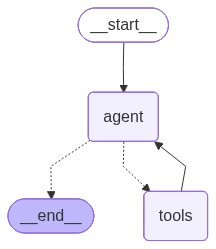

In [5]:
# Display the graph structure
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback: print mermaid diagram
    print(graph.get_graph().draw_mermaid())

## 5. Memory Setup

Memory is built into the **AgentState**.
The `add_messages` reducer appends every new message to `state["messages"]`,
so the agent always sees the **full conversation history** — no extra setup needed!

We maintain a simple list of messages between calls:

In [6]:
from langchain_core.messages import HumanMessage

# Conversation memory: stores all messages for the current session
conversation_history = []

def chat(user_input: str, verbose: bool = False) -> str:
    """
    Send a message to the hotel assistant and get a response.
    Memory is preserved across calls via conversation_history.
    
    Args:
        user_input: The user's message
        verbose: If True, print intermediate steps (tool calls)
    Returns:
        The assistant's final response string
    """
    global conversation_history
    
    # Add the new user message to history
    conversation_history.append(HumanMessage(content=user_input))
    
    # Run the graph with the full history
    result = graph.invoke({"messages": conversation_history})
    
    # Get all new messages added during this run
    new_messages = result["messages"][len(conversation_history):]
    
    # Update history with everything from this run
    conversation_history = result["messages"]
    
    # Verbose: show intermediate tool steps
    if verbose:
        for msg in new_messages[:-1]:  # all except final
            if hasattr(msg, 'tool_calls') and msg.tool_calls:
                for tc in msg.tool_calls:
                    print(f"  🔧 Tool called: {tc['name']}")
                    print(f"     Args: {tc['args']}")
    
    # Return the final AI response
    final = result["messages"][-1]
    return final.content


def reset_conversation():
    """Clear conversation memory to start a fresh session."""
    global conversation_history
    conversation_history = []
    print("🔄 Conversation memory cleared.")


print("✅ Chat function ready with memory.")

✅ Chat function ready with memory.


## 6. Test the Agent

Let's run through several test scenarios to verify everything works.

In [7]:
# ── Test 1: General hotel info (RAG)
reset_conversation()
print("=" * 60)
print("TEST 1: General Information (RAG)")
print("=" * 60)

response = chat("What restaurants does the hotel have?", verbose=True)
print(f"\n🤖 Assistant: {response}")

🔄 Conversation memory cleared.
TEST 1: General Information (RAG)
  🔧 Tool called: search_hotel_info
     Args: {'query': 'restaurants'}

🤖 Assistant: At the Grand Azure Hotel, we offer a variety of dining options to cater to your culinary preferences:

1. **The Nile Grill (Floor 1 – Main Restaurant)**
   - Cuisine: International Buffet and À la carte
   - Breakfast Buffet: 6:30 AM – 10:30 AM ($25/person, free for Suite and above)
   - Lunch: 12:30 PM – 3:30 PM
   - Dinner: 7:00 PM – 11:00 PM
   - Dress code: Smart casual
   - Reservations recommended for dinner (ext. 810)

2. **Cairo Kitchen (Floor 1 – Casual Dining)**
   - Cuisine: Traditional Egyptian and Middle Eastern food
   - Hours: 11:00 AM – 11:00 PM
   - Signature dishes: Koshary, Feteer Meshaltet, Grilled Kofta, Fattah
   - Family-friendly atmosphere

3. **Sushi Nile (Floor 3)**
   - Cuisine: Japanese and Pan-Asian
   - Hours: 1:00 PM – 11:00 PM (Closed Mondays)
   - Signature dishes: Dragon Roll, Black Miso Ramen, Wagyu Beef

In [8]:
# ── Test 2: Room availability (SQL)
print("=" * 60)
print("TEST 2: Check Availability (SQL)")
print("=" * 60)

reset_conversation()
response = chat("I'm looking for a Deluxe room. Are any available?", verbose=True)
print(f"\n🤖 Assistant: {response}")

TEST 2: Check Availability (SQL)
🔄 Conversation memory cleared.
  🔧 Tool called: check_room_availability
     Args: {'room_type': 'Deluxe'}

🤖 Assistant: We have several Deluxe rooms available:

- Room 601 on the 6th floor for $130.00 per night
- Room 603 on the 6th floor for $130.00 per night
- Room 701 on the 7th floor for $130.00 per night
- Room 702 on the 7th floor for $130.00 per night

Would you like to proceed with booking one of these rooms? If so, please let me know your preferred room number and your check-in and check-out dates.


In [9]:
# ── Test 3: Full booking flow with memory
print("=" * 60)
print("TEST 3: Full Booking Flow (Memory across turns)")
print("=" * 60)

reset_conversation()

turn1 = chat("Hi! I'd like to book a Standard room.")
print(f"Turn 1 — User: 'I'd like to book a Standard room.'")
print(f"🤖 {turn1}\n")

turn2 = chat("My name is Youssef Nabil. Please book room 201 from 2025-08-10 to 2025-08-13.", verbose=True)
print(f"Turn 2 — User: 'My name is Youssef Nabil...'")
print(f"🤖 {turn2}\n")

turn3 = chat("What was my total price again?")
print(f"Turn 3 — User: 'What was my total price again?' (tests memory)")
print(f"🤖 {turn3}")

TEST 3: Full Booking Flow (Memory across turns)
🔄 Conversation memory cleared.
Turn 1 — User: 'I'd like to book a Standard room.'
🤖 I'd be happy to help you with that! Could you please provide me with your full name, as well as your desired check-in and check-out dates?

  🔧 Tool called: check_room_availability
     Args: {'room_type': 'Standard'}
  🔧 Tool called: book_room
     Args: {'guest_name': 'Youssef Nabil', 'room_number': '201', 'check_in': '2025-08-10', 'check_out': '2025-08-13'}
Turn 2 — User: 'My name is Youssef Nabil...'
🤖 Your booking has been successfully confirmed! Here are the details:

- **Guest Name:** Youssef Nabil
- **Room Number:** 201 (Standard)
- **Check-In Date:** August 10, 2025
- **Check-Out Date:** August 13, 2025
- **Total Nights:** 3
- **Total Price:** $240.00

If you have any other questions or need further assistance, feel free to ask!

Turn 3 — User: 'What was my total price again?' (tests memory)
🤖 Your total price for the stay in Room 201 is **$240.00

In [10]:
# ── Test 4: Look up existing booking
print("=" * 60)
print("TEST 4: Booking Lookup (SQL JOIN)")
print("=" * 60)

reset_conversation()
response = chat("Can you look up my booking? My name is Ahmed Hassan.", verbose=True)
print(f"🤖 {response}")

TEST 4: Booking Lookup (SQL JOIN)
🔄 Conversation memory cleared.
  🔧 Tool called: get_booking_details
     Args: {'guest_name': 'Ahmed Hassan'}
🤖 I found your booking, Ahmed Hassan. Here are the details:

- **Room:** 203 (Standard)
- **Check-In Date:** July 10, 2025
- **Check-Out Date:** July 13, 2025
- **Total Price:** $240.00
- **Status:** Confirmed

If you need any further assistance or changes, feel free to let me know!


In [11]:
# ── Test 5: Policies (RAG)
print("=" * 60)
print("TEST 5: Hotel Policy Question (RAG)")
print("=" * 60)

reset_conversation()
response = chat("What is your cancellation policy?", verbose=True)
print(f"🤖 {response}")

TEST 5: Hotel Policy Question (RAG)
🔄 Conversation memory cleared.
  🔧 Tool called: search_hotel_info
     Args: {'query': 'cancellation policy'}
🤖 Our cancellation policy at Grand Azure Hotel is as follows:

- **Free cancellation** up to 48 hours before the check-in date.
- Cancellations made within 48 hours of check-in will incur a **1-night charge**.
- In case of a **no-show**, the full stay will be charged.
- For **non-refundable rates**, cancellations or modifications are not allowed.

If you have any further questions or need assistance with a booking, feel free to ask!


## 7. Interactive Chat Loop

Run this cell to chat with the hotel assistant interactively.
Type `quit` or `exit` to stop. Type `reset` to clear memory.

In [ ]:
reset_conversation()

print("="*60)
print("🏨  Welcome to Grand Azure Hotel AI Assistant")
print("="*60)
print("Type your question below. Commands: 'reset' | 'quit'")
print()

while True:
    user_input = input("You: ").strip()
    
    if not user_input:
        continue
    if user_input.lower() in ("quit", "exit", "q"):
        print("Goodbye! Have a wonderful stay at Grand Azure Hotel. 🌟")
        break
    if user_input.lower() == "reset":
        reset_conversation()
        continue
    
    print()
    response = chat(user_input, verbose=True)   # verbose=False to hide tool steps
    print(f"🤖 Assistant: {response}")
    print(f"   [Memory: {len(conversation_history)} messages stored]")
    print()

🔄 Conversation memory cleared.
🏨  Welcome to Grand Azure Hotel AI Assistant
Type your question below. Commands: 'reset' | 'quit'



You:  hi there



🤖 Assistant: Hello! Welcome to the Grand Azure Hotel. How can I assist you today?
   [Memory: 2 messages stored]



You:  Is there double room free to book?



  🔧 Tool called: check_room_availability
     Args: {'room_type': 'Deluxe'}
🤖 Assistant: We have several Deluxe rooms available for booking. Here are the details:

- Room 601: Floor 6, Price: $130.00 per night
- Room 603: Floor 6, Price: $130.00 per night
- Room 701: Floor 7, Price: $130.00 per night
- Room 702: Floor 7, Price: $130.00 per night

Would you like to proceed with booking one of these rooms? If so, please let me know your check-in and check-out dates, as well as your name.
   [Memory: 6 messages stored]



You:  check-in is 13-5 and check-out is 15-5



🤖 Assistant: Thank you for the information! Just to confirm, would you like to book one of the available Deluxe rooms for the dates of May 13th to May 15th? If so, please provide your name, and let me know which room you would like to book (601, 603, 701, or 702).
   [Memory: 8 messages stored]



You:  Goal Gamal, 601



  🔧 Tool called: book_room
     Args: {'guest_name': 'Goal Gamal', 'room_number': '601', 'check_in': '2024-05-13', 'check_out': '2024-05-15'}
🤖 Assistant: Your booking has been confirmed! Here are the details:

- **Guest Name:** Goal Gamal
- **Room Number:** 601 (Deluxe)
- **Check-In Date:** May 13, 2024
- **Check-Out Date:** May 15, 2024
- **Total Price:** $260.00 for 2 nights

If you have any other questions or need further assistance, feel free to ask. We look forward to welcoming you to the Grand Azure Hotel!
   [Memory: 12 messages stored]



---
## ✅ Project Complete!

### Summary of What Was Built

| Component | Implementation |
|---|---|
| **LangChain** | Tool definitions, embeddings, document loading |
| **LangGraph** | StateGraph with agent + tool nodes, conditional routing |
| **RAG** | FAISS vector store from 6 hotel documents, retriever |
| **Tools** | 4 tools: RAG search, SQL availability, SQL lookup, SQL booking |
| **Memory** | `add_messages` reducer keeps full conversation history in state |

### Architecture Explained
1. **User sends message** → added to `AgentState.messages`
2. **`agent` node** → LLM sees full history + system prompt → decides action
3. **If tool call** → `tools` node executes the tool → result added to messages → back to agent
4. **If no tool call** → agent gives final answer → `END`
5. **Memory**: `conversation_history` list grows every turn — agent always has full context

### Routing Logic (How the agent decides)
- `tools_condition()` checks if the last message has `tool_calls`
- If yes → route to `tools` node
- If no → route to `END`
- The LLM is trained to output tool calls when it needs external data